In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd #para cargar datos
import numpy as np #operaciones matetmaticas y vectores
import matplotlib.pyplot as plt #hacer graficas
import statsmodels.formula.api as smf #para regresiones
import seaborn as sns #para correlacion
import statsmodels.api as sm #Ver graficamente la heterocedasticidad
import statsmodels.stats.diagnostic as sm_diagnostic #Ver graficamente la heterocedasticidad

#Descripcion
Mi conjunto de datos titulado "TFG 1", esta relacionada con el BCM de los egresados a cuatro años de las universidades publica y privadas con distintos campos de estudio.

El objetivo principal es estudiar los distintos salarios entre personas que egresan de una universidad a otra.

#Hipotesis
Vamos a estudiar si el estudiar en una universidad privada o publica tiene efecto en el salario al egresar de la universidad.


Defino $Y$ como el salario (BCM) al y como $X$ tenemos varias variables incluida dummys.

El modelo poblacional es:
$Y_i = \beta_0 + \beta_1 X_i + u_i$

La hipótesis teórica es que la relación de nuestras variables sea que dependiendo del campo y la universidad $\beta_1$ sea positiva, pero dependidendo de nuestra $X$, tenga mayores o menores valores.


Y = BCM Anual

X1= Dummy Privada ( 1 privada, 0 publica)

X2= Año (valores entre 1 a 4 por año egresado)

X3= Dummy sexo ( 1 mujer, 0 hombre)

X4= Areas (Se agruparan en 5 grandes grupos)

XXX= Los demas BCM, no se usaran como variable porque ya esta en la Y, pero se pueden usar para hacer graficos.






**VARIABLES**

Estudiamos nuestras variables

In [ ]:
datos = pd.read_csv('/content/drive/MyDrive/datos1.csv')
datos.head() #muestra los 5 primeros de la tabla

,Carrera,Tipo_Uni,Género,Anio,BCM. Anual,BCM. De 12.000 a 18.000,BCM. De 18.000 a 24.000,BCM. De 24.000 a 30.000,BCM. De 30.000 a 36.000,BCM. Más de 36.000,Area
0,Actividad física y del deporte,Privada,Hombre,1,21486.71,47.97,25.20,11.38,6.50,8.94,Sociales y Jurídicas
1,Actividad física y del deporte,Privada,Hombre,2,21696.06,43.51,29.87,11.69,7.14,7.79,Sociales y Jurídicas
2,Actividad física y del deporte,Privada,Hombre,3,23024.01,37.44,30.84,13.66,5.29,12.78,Sociales y Jurídicas
3,Actividad física y del deporte,Privada,Hombre,4,26045.58,25.91,28.57,16.94,9.30,19.27,Sociales y Jurídicas
4,Actividad física y del deporte,Privada,Mujer,3,25116.71,14.81,48.15,11.11,11.11,14.81,Sociales y Jurídicas


In [ ]:
datos['Tipo_Uni'].value_counts()

,count
Tipo_Uni,
Pública,336
Privada,267


In [ ]:
datos['Carrera'].value_counts()

,count
Carrera,
Administración y empresa,16
Arquitectura,16
"Audiovisual, imagen y multimedia",16
Educación infantil,16
Derecho,16
Psicología,16
Ingeniería de organización industrial,16
Ingeniería en diseño industrial y desarrollo del producto,16
Ingeniería mecánica,16


In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Carrera                  603 non-null    object 
 1   Tipo_Uni                 603 non-null    object 
 2   Género                   603 non-null    object 
 3   Anio                     603 non-null    int64  
 4   BCM. Anual               603 non-null    float64
 5   BCM. De 12.000 a 18.000  565 non-null    float64
 6   BCM. De 18.000 a 24.000  578 non-null    float64
 7   BCM. De 24.000 a 30.000  572 non-null    float64
 8   BCM. De 30.000 a 36.000  567 non-null    float64
 9   BCM. Más de 36.000       568 non-null    float64
 10  Area                     603 non-null    object 
dtypes: float64(6), int64(1), object(4)
memory usage: 51.9+ KB


In [ ]:
#Estadistica descriptiva
datos.describe()


,Anio,BCM. Anual,BCM. De 12.000 a 18.000,BCM. De 18.000 a 24.000,BCM. De 24.000 a 30.000,BCM. De 30.000 a 36.000,BCM. Más de 36.000
count,603.000000,603.000000,565.000000,578.000000,572.000000,567.000000,568.000000
mean,2.557214,25916.542687,25.445947,25.235657,19.143234,13.867989,17.092606
std,1.113774,5543.775999,19.382030,12.191691,9.237070,10.681657,16.004329
min,1.000000,15609.710000,0.030000,1.200000,0.910000,0.820000,0.790000
25%,2.000000,21573.755000,8.570000,16.247500,12.470000,6.890000,5.880000
50%,3.000000,24956.730000,21.430000,25.555000,18.435000,10.710000,10.850000
75%,4.000000,29768.815000,39.730000,33.487500,24.095000,17.885000,23.820000
max,4.000000,42115.210000,81.580000,69.570000,58.950000,60.110000,85.630000


In [ ]:
datos.value_counts()

Carrera                         Tipo_Uni  Género  Anio  BCM. Anual  BCM. De 12.000 a 18.000  BCM. De 18.000 a 24.000  BCM. De 24.000 a 30.000  BCM. De 30.000 a 36.000  BCM. Más de 36.000  Area                
Veterinaria                     Pública   Mujer   4     26217.23    5.32                     44.57                    31.26                    7.98                     10.86               Salud                   1
Actividad física y del deporte  Privada   Hombre  1     21486.71    47.97                    25.20                    11.38                    6.50                     8.94                Sociales y Jurídicas    1
                                                  2     21696.06    43.51                    29.87                    11.69                    7.14                     7.79                Sociales y Jurídicas    1
                                                  3     23024.01    37.44                    30.84                    13.66                    5.29                     12.78               Sociales y Jurídicas    1
                                                  4     26045.58    25.91                    28.57                    16.94                    9.30                     19.27               Sociales y Jurídicas    1
                                                                                                                                                                                                                   ..
Administración y empresa        Privada   Mujer   1     22381.80    37.27                    21.76                    25.32                    6.97                     8.68                Sociales y Jurídicas    1
                                          Hombre  4     36661.38    5.29                     9.53                     17.53                    17.06                    50.59               Sociales y Jurídicas    1
                                                  3     31439.21    10.42                    17.21                    21.31                    19.56                    31.50               Sociales y Jurídicas    1
                                                  2     26812.21    21.83                    23.28                    23.28                    12.30                    19.30               Sociales y Jurídicas    1
                                                  1     24095.12    29.79                    25.80                    22.87                    8.24                     13.30               Sociales y Jurídicas    1
Name: count, Length: 509, dtype: int64

In [ ]:
datos.isnull().sum()

,0
Carrera,0
Tipo_Uni,0
Género,0
Anio,0
BCM. Anual,0
BCM. De 12.000 a 18.000,38
BCM. De 18.000 a 24.000,25
BCM. De 24.000 a 30.000,31
BCM. De 30.000 a 36.000,36
BCM. Más de 36.000,35


#eliminar datos usar el datos = datos.dropna(), si fuera necesario

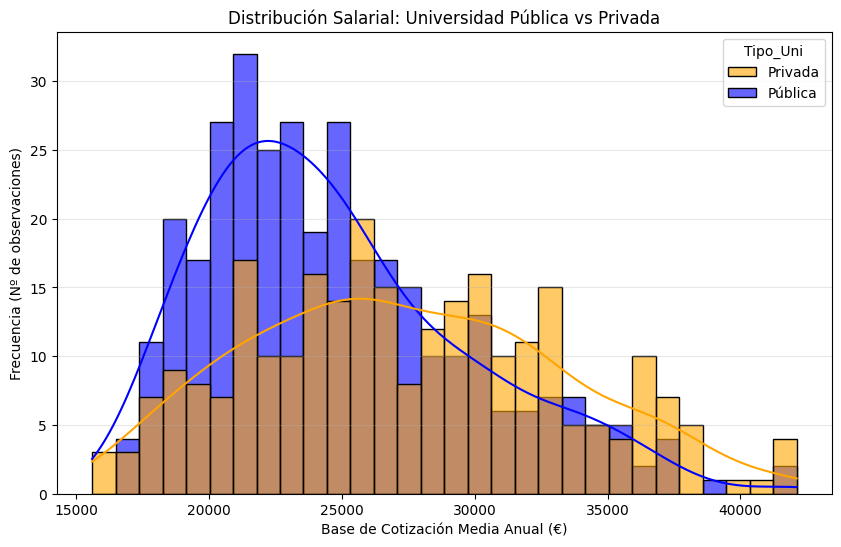

In [ ]:
#Geminis
fig = plt.figure(figsize=(10, 6))
sns.histplot(data=datos, x='BCM. Anual', hue='Tipo_Uni', bins=30, kde=True,
             palette={'Pública': 'blue', 'Privada': 'orange'}, alpha=0.6)

plt.xlabel('Base de Cotización Media Anual (€)')
plt.ylabel('Frecuencia (Nº de observaciones)')
plt.title('Distribución Salarial: Universidad Pública vs Privada')
plt.grid(axis='y', alpha=0.3)
plt.show()

#CUMPLIMIENTOS DEL MODELO ECONOMETRICO (MCO)

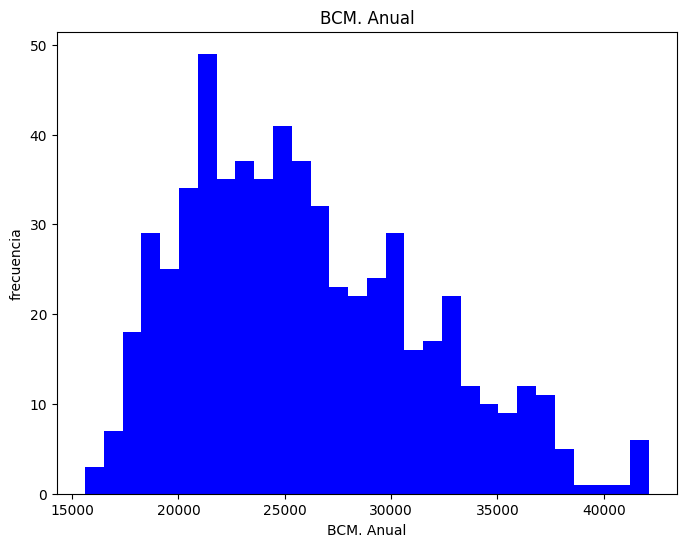

In [ ]:
#Para saber si se cumplen con los supuestos de MCO se deberan de hacer graficas
#Para ello estudiamos la distribucion de la Y, que es nuestra variable a explicar.
fig = plt.figure(figsize=(8,6))
plt.hist(datos['BCM. Anual'], bins=30, color = 'blue')
plt.xlabel('BCM. Anual')
plt.ylabel('frecuencia')
plt.title('BCM. Anual')
plt.show()

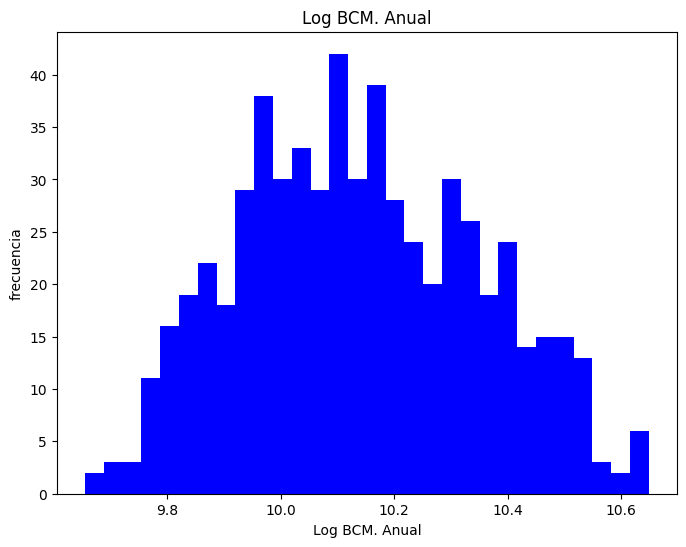

In [ ]:
#Ya que no puedo transformar mis variables X porque son Dummys y no tiene sentido. Voy a transformar mi variable Y que aunque tiene forma de campana quiero tener los datos para interpretar de %
datos['Log_Salario'] = np.log(datos['BCM. Anual'])
fig = plt.figure(figsize=(8,6))
plt.hist(np.log(datos['BCM. Anual'] + 1), bins=30, color = 'blue')
plt.xlabel('Log BCM. Anual')
plt.ylabel('frecuencia')
plt.title('Log BCM. Anual')
plt.show()


In [ ]:
#CONVERTIR VARIABLES QUE TIENEN PALABRA EN DUMMY PARA LEERLO
datos['Dummy_Privada'] = (datos['Tipo_Uni'] == 'Privada').astype(int)
datos['Dummy_Mujer'] = (datos['Género'] == 'Mujer').astype(int)
columnas_modelo = ['BCM. Anual', 'Anio', 'Dummy_Privada', 'Dummy_Mujer']
datos_correlacion = datos[columnas_modelo]

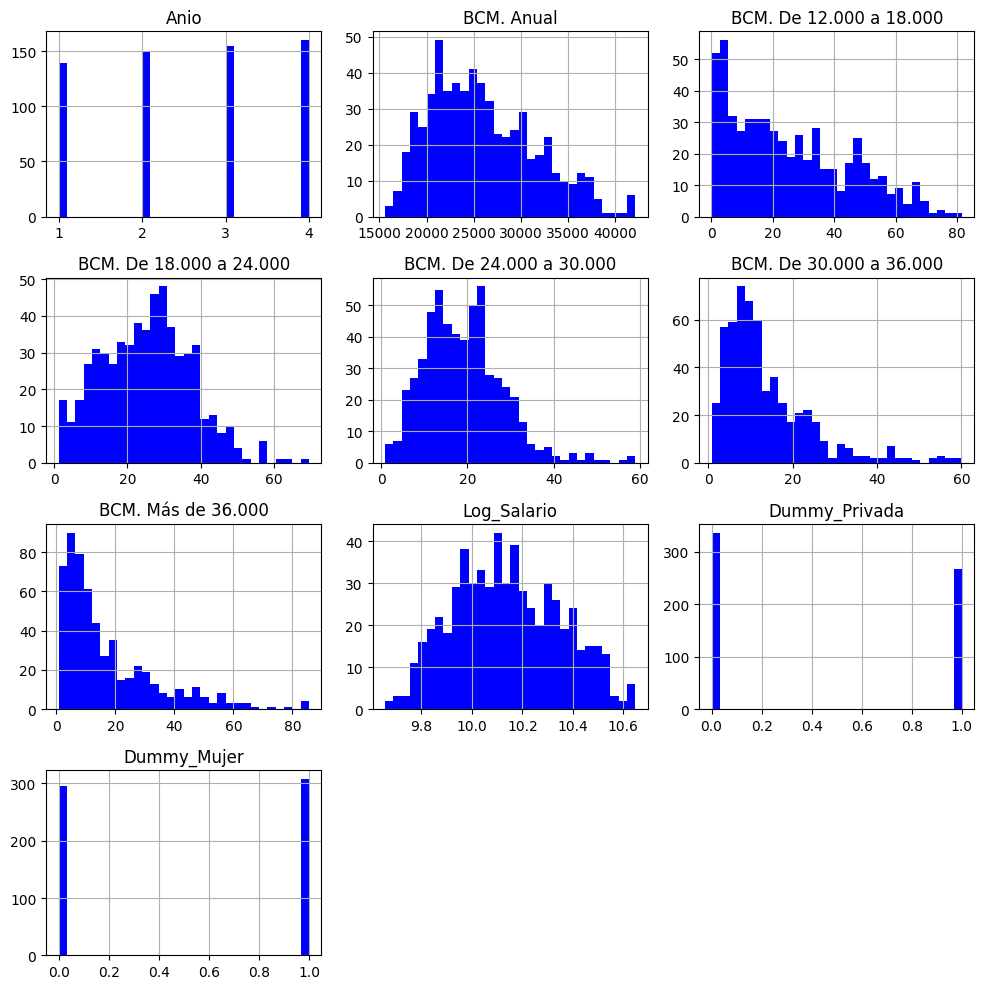

In [ ]:
#Ver las demas GRAFICAS de nuestras variables X

import matplotlib.pyplot as plt

datos.hist(figsize=(10,10),bins=30, color='blue')
plt.tight_layout()
plt.show()

In [ ]:
#Dummy
dummies = pd.get_dummies(datos['Dummy_Privada'], prefix='Uni', drop_first=True)
datos = pd.concat([datos, dummies], axis=1)
datos.head()

,Carrera,Tipo_Uni,Género,Anio,BCM. Anual,BCM. De 12.000 a 18.000,BCM. De 18.000 a 24.000,BCM. De 24.000 a 30.000,BCM. De 30.000 a 36.000,BCM. Más de 36.000,Area,Log_Salario,Dummy_Privada,Dummy_Mujer,Uni_1
0,Actividad física y del deporte,Privada,Hombre,1,21486.71,47.97,25.20,11.38,6.50,8.94,Sociales y Jurídicas,9.975190,1,0,True
1,Actividad física y del deporte,Privada,Hombre,2,21696.06,43.51,29.87,11.69,7.14,7.79,Sociales y Jurídicas,9.984886,1,0,True
2,Actividad física y del deporte,Privada,Hombre,3,23024.01,37.44,30.84,13.66,5.29,12.78,Sociales y Jurídicas,10.044293,1,0,True
3,Actividad física y del deporte,Privada,Hombre,4,26045.58,25.91,28.57,16.94,9.30,19.27,Sociales y Jurídicas,10.167603,1,0,True
4,Actividad física y del deporte,Privada,Mujer,3,25116.71,14.81,48.15,11.11,11.11,14.81,Sociales y Jurídicas,10.131289,1,1,True


In [ ]:
datos[dummies.columns].head()

,Uni_1
0,True
1,True
2,True
3,True
4,True


In [ ]:
pd.get_dummies(datos['Dummy_Privada'], prefix='Uni', drop_first=True)

,Uni_1
0,True
1,True
2,True
3,True
4,True
...,...
598,False
599,False
600,False
601,False


In [ ]:
#Dummy
dummies = pd.get_dummies(datos['Dummy_Privada'], prefix='Uni', drop_first=True)
datos = pd.concat([datos, dummies], axis=1)
datos.head()

,Carrera,Tipo_Uni,Género,Anio,BCM. Anual,BCM. De 12.000 a 18.000,BCM. De 18.000 a 24.000,BCM. De 24.000 a 30.000,BCM. De 30.000 a 36.000,BCM. Más de 36.000,Area,Log_Salario,Dummy_Privada,Dummy_Mujer,Uni_1,Uni_1
0,Actividad física y del deporte,Privada,Hombre,1,21486.71,47.97,25.20,11.38,6.50,8.94,Sociales y Jurídicas,9.975190,1,0,True,True
1,Actividad física y del deporte,Privada,Hombre,2,21696.06,43.51,29.87,11.69,7.14,7.79,Sociales y Jurídicas,9.984886,1,0,True,True
2,Actividad física y del deporte,Privada,Hombre,3,23024.01,37.44,30.84,13.66,5.29,12.78,Sociales y Jurídicas,10.044293,1,0,True,True
3,Actividad física y del deporte,Privada,Hombre,4,26045.58,25.91,28.57,16.94,9.30,19.27,Sociales y Jurídicas,10.167603,1,0,True,True
4,Actividad física y del deporte,Privada,Mujer,3,25116.71,14.81,48.15,11.11,11.11,14.81,Sociales y Jurídicas,10.131289,1,1,True,True


In [ ]:
datos[dummies.columns].head()

,Uni_1,Uni_1
0,True,True
1,True,True
2,True,True
3,True,True
4,True,True


/tmp/ipykernel_1617/1521152737.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos, x='Tipo_Uni', y='BCM. Anual', ax=axes[0], palette='Set1')
/tmp/ipykernel_1617/1521152737.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos, x='Género', y='BCM. Anual', ax=axes[1], palette='Set2')
/tmp/ipykernel_1617/1521152737.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos, x='Anio', y='BCM. Anual', ax=axes[2], palette='Set3')


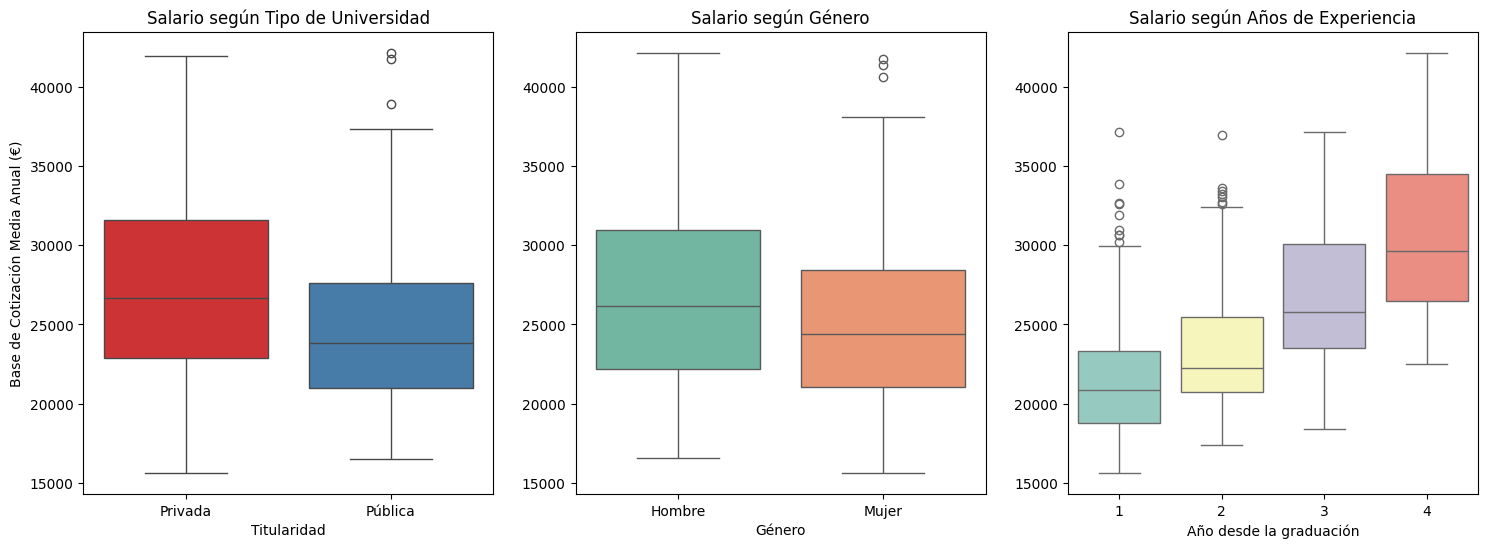

In [ ]:
#Para mis variables cualitativas utilizare BoxPlot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(data=datos, x='Tipo_Uni', y='BCM. Anual', ax=axes[0], palette='Set1')
axes[0].set_title('Salario según Tipo de Universidad')
axes[0].set_ylabel('Base de Cotización Media Anual (€)')
axes[0].set_xlabel('Titularidad')

sns.boxplot(data=datos, x='Género', y='BCM. Anual', ax=axes[1], palette='Set2')
axes[1].set_title('Salario según Género')
axes[1].set_ylabel('') # Lo quitamos para no saturar
axes[1].set_xlabel('Género')

sns.boxplot(data=datos, x='Anio', y='BCM. Anual', ax=axes[2], palette='Set3')
axes[2].set_title('Salario según Años de Experiencia')
axes[2].set_ylabel('')
axes[2].set_xlabel('Año desde la graduación')

plt.show()

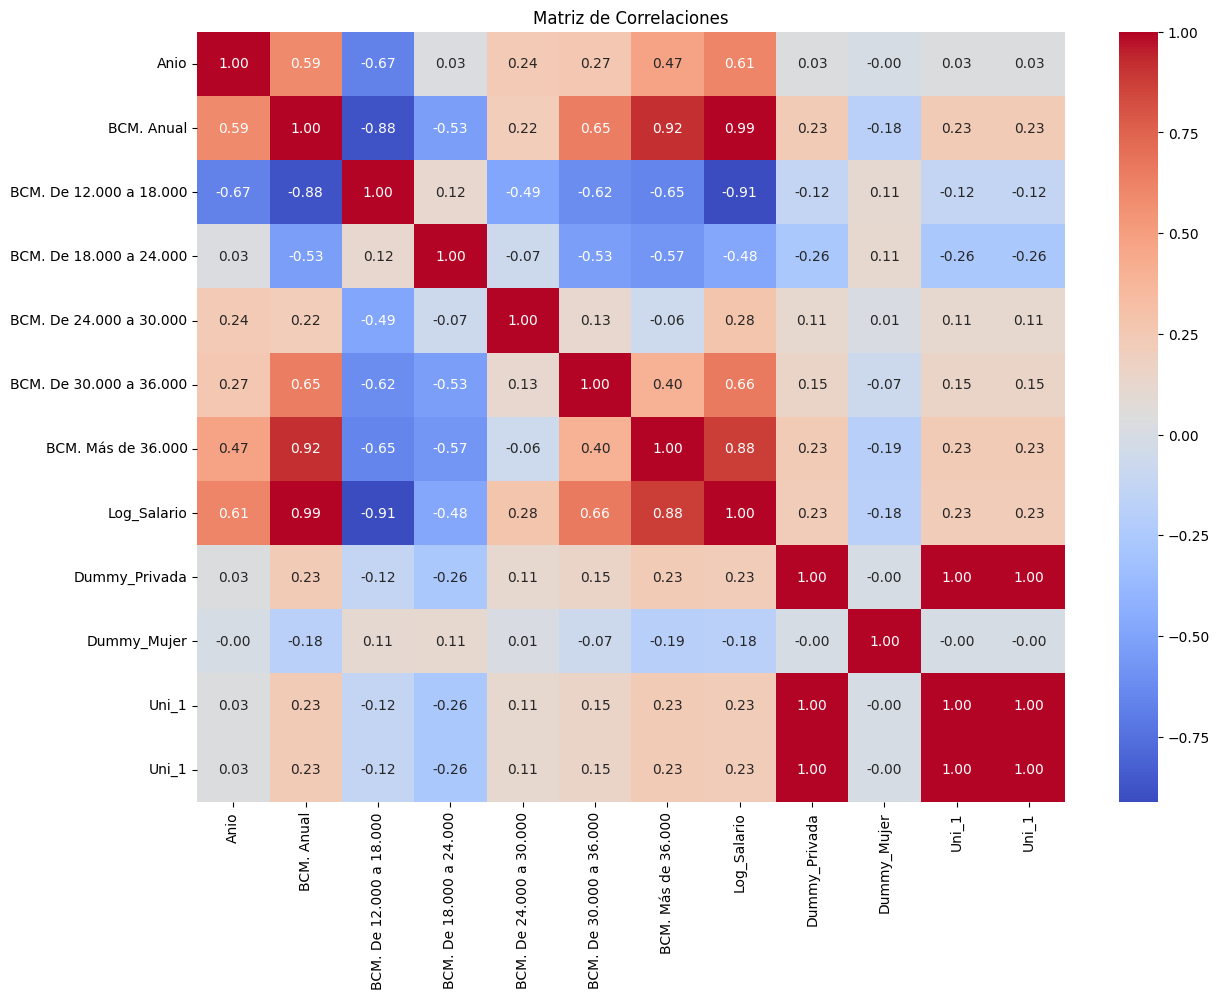

In [ ]:
#Ahora miraremos la matriz de correlaciones para ver cuanto depende nuestras variables unas de otras, es decir,
#si tienen la misma informacion que aportar. Si es cercano a 1 es que son variables que tiene misma matriz, por lo que tendran determinante 0 y hacen infinito los SCR, incumpliendo los supuestos de G-M

import seaborn as sns

# Calcular la matriz de correlaciones
correlation_matrix = datos.corr(numeric_only=True)

# Mostrar la matriz de correlaciones
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlaciones')
plt.show()

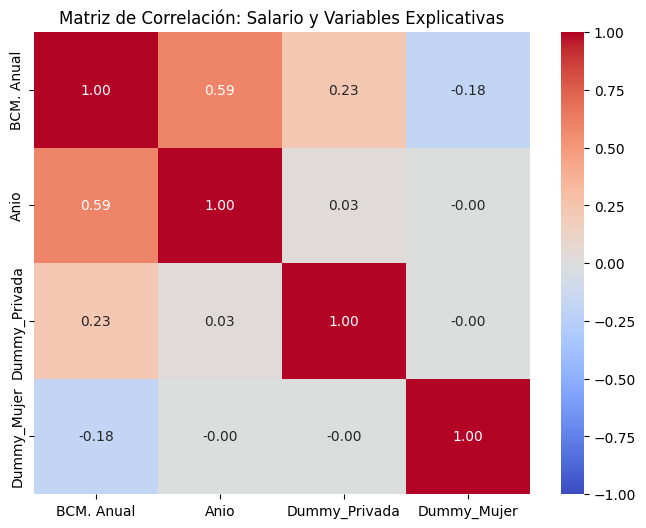

In [ ]:
#Aqui en formato reducido quitando las variables de BCM
matriz_corr = datos_correlacion.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación: Salario y Variables Explicativas')
plt.show()

ESTIMACION DE MODELOS

In [ ]:
#Regresion lineal simple

modelo = smf.ols("Q('BCM. Anual') ~ Dummy_Privada", data=datos).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:        Q('BCM. Anual')   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     34.52
Date:                Sun, 24 May 2026   Prob (F-statistic):           7.00e-09
Time:                        09:55:48   Log-Likelihood:                -6036.4
No. Observations:                 603   AIC:                         1.208e+04
Df Residuals:                     601   BIC:                         1.209e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      2.477e+04    294.354     84.136

In [ ]:
modelo = smf.ols("Q('BCM. Anual') ~ Dummy_Mujer", data=datos).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:        Q('BCM. Anual')   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     20.62
Date:                Sun, 24 May 2026   Prob (F-statistic):           6.78e-06
Time:                        09:55:48   Log-Likelihood:                -6043.1
No. Observations:                 603   AIC:                         1.209e+04
Df Residuals:                     601   BIC:                         1.210e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    2.695e+04    317.638     84.837      

In [ ]:
modelo = smf.ols("Q('BCM. Anual') ~ Anio", data=datos).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:        Q('BCM. Anual')   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     328.0
Date:                Sun, 24 May 2026   Prob (F-statistic):           7.88e-59
Time:                        09:55:49   Log-Likelihood:                -5921.9
No. Observations:                 603   AIC:                         1.185e+04
Df Residuals:                     601   BIC:                         1.186e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.835e+04    455.431     40.298      0.0

In [ ]:
#Todas juntas

modelo = smf.ols("Q('BCM. Anual') ~ Anio + Dummy_Mujer + Dummy_Privada", data=datos).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:        Q('BCM. Anual')   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.428
Method:                 Least Squares   F-statistic:                     151.4
Date:                Sun, 24 May 2026   Prob (F-statistic):           5.18e-73
Time:                        09:55:49   Log-Likelihood:                -5883.1
No. Observations:                 603   AIC:                         1.177e+04
Df Residuals:                     599   BIC:                         1.179e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       1.84e+04    483.558     38.051

                               OLS Regression Results                              
Dep. Variable:     np.log(Q('BCM. Anual'))   R-squared:                       0.454
Model:                                 OLS   Adj. R-squared:                  0.451
Method:                      Least Squares   F-statistic:                     165.8
Date:                     Sun, 24 May 2026   Prob (F-statistic):           3.00e-78
Time:                             09:55:49   Log-Likelihood:                 268.74
No. Observations:                      603   AIC:                            -529.5
Df Residuals:                          599   BIC:                            -511.9
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

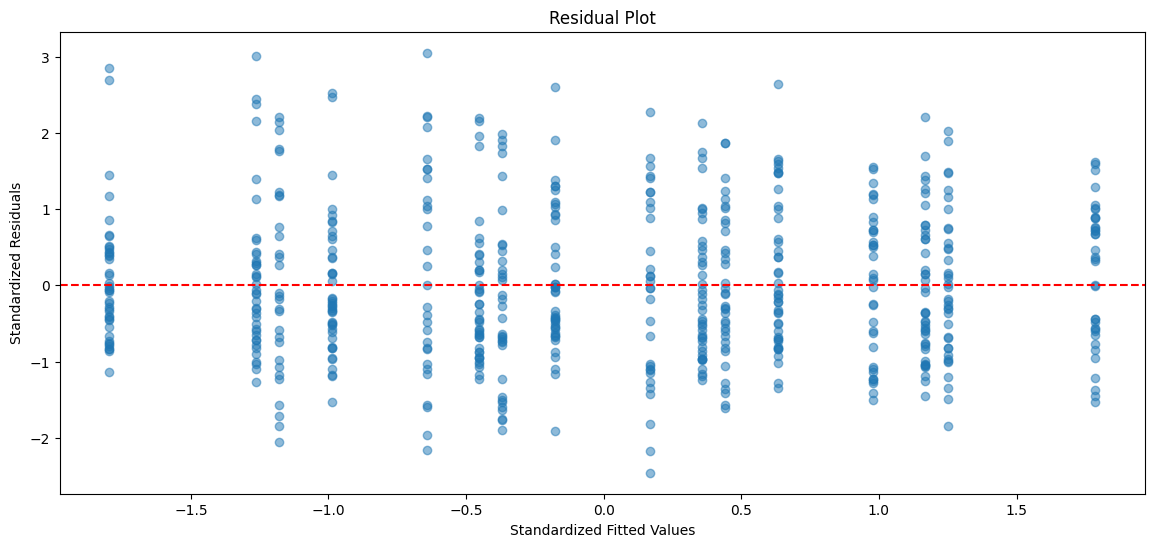

In [ ]:
#Y ahora con Log en la variable dependiente.

modelo = smf.ols("np.log(Q('BCM. Anual')) ~ Anio + Dummy_Mujer + Dummy_Privada", data=datos).fit()
print(modelo.summary())

#valores estimados

fitted_values = modelo.fittedvalues
standardized_fitted = (fitted_values - fitted_values.mean()) / fitted_values.std()


#Residuos
residuals = modelo.resid
standardized_residuals = (residuals - residuals.mean()) / residuals.std()

#graficamente

fig = plt.figure(figsize=(14,6))
plt.scatter(standardized_fitted, standardized_residuals, alpha=0.5)
plt.axhline (0, color = 'red', linestyle = '--')
plt.xlabel('Standardized Fitted Values')
plt.ylabel('Standardized Residuals')
plt.title('Residual Plot')
plt.show()

PARA LA HETEROCEDASTICIDAD

In [ ]:
#Una vez visto graficamente que se puede ver heterocedasticidad, aplico los metodos analiticos /(contrastes)


GQ_inc = sm_diagnostic.het_goldfeldquandt(modelo.resid, modelo.model.exog,alternative='increasing')
print("Goldfeld–Quandt (increasing):", GQ_inc)

Goldfeld–Quandt (increasing): (np.float64(1.282817822191525), np.float64(0.016034310336511353), 'increasing')


In [ ]:
GQ_inc = sm_diagnostic.het_goldfeldquandt(modelo.resid, modelo.model.exog,alternative='Decreasing')
print("Goldfeld–Quandt (Decreasing):", GQ_inc)

Goldfeld–Quandt (Decreasing): (np.float64(1.282817822191525), np.float64(0.9839656896634886), 'decreasing')


In [ ]:
GQ_inc = sm_diagnostic.het_goldfeldquandt(modelo.resid, modelo.model.exog,alternative='Two-Sided')
print("Goldfeld–Quandt (Two-Sided):", GQ_inc)

Goldfeld–Quandt (Two-Sided): (np.float64(1.282817822191525), np.float64(0.03210295228772552), 'two-sided')


In [ ]:
#Tambien podemos hacer Breush-pagan
BP = sm_diagnostic.het_breuschpagan( modelo.resid,modelo.model.exog)
print("Breusch–Pagan:", BP)

Breusch–Pagan: (np.float64(18.574660720860773), np.float64(0.0003347312753604312), np.float64(6.345961308202505), np.float64(0.0003068913305867912))


HETEROCEDASTICADAD


In [ ]:
#En este caso usaremos EER donde se corrigio los efectos sobre la inferencia.

modelo_robusto = modelo.get_robustcov_results(cov_type='HC3')
print(modelo_robusto.summary())

                               OLS Regression Results                              
Dep. Variable:     np.log(Q('BCM. Anual'))   R-squared:                       0.454
Model:                                 OLS   Adj. R-squared:                  0.451
Method:                      Least Squares   F-statistic:                     183.4
Date:                     Sun, 24 May 2026   Prob (F-statistic):           2.36e-84
Time:                             09:55:49   Log-Likelihood:                 268.74
No. Observations:                      603   AIC:                            -529.5
Df Residuals:                          599   BIC:                            -511.9
Df Model:                                3                                         
Covariance Type:                       HC3                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

Teniendo STEM que es ciencia, tecnogogia, ingenieria y matematicas

In [ ]:
# 1. CREAMOS LA VARIABLE 'Area' AGRUPANDO LAS CARRERAS
mapping = {
    'Administración y empresa': 'Sociales y Jurídicas',
    'Arquitectura': 'STEM',
    'Audiovisual, imagen y multimedia': 'Artes y Humanidades',
    'Educación infantil': 'Educación',
    'Derecho': 'Sociales y Jurídicas',
    'Psicología': 'Salud',
    'Ingeniería de organización industrial': 'STEM',
    'Ingeniería en diseño industrial y desarrollo del producto': 'STEM',
    'Ingeniería mecánica': 'STEM',
    'Informática': 'STEM',
    'Fisioterapia': 'Salud',
    'Farmacia': 'Salud',
    'Enfermería': 'Salud',
    'Educación primaria': 'Educación',
    'Medicina': 'Salud',
    'Periodismo': 'Sociales y Jurídicas',
    'Veterinaria': 'Salud',
    'Publicidad y relaciones públicas': 'Sociales y Jurídicas',
    'Marketing': 'Sociales y Jurídicas',
    'Nutrición humana y dietética': 'Salud',
    'Ingeniería en tecnologías industriales': 'STEM',
    'Turismo': 'Sociales y Jurídicas',
    'Actividad física y del deporte': 'Sociales y Jurídicas',
    'Biotecnología': 'STEM',
    'Diseño': 'Artes y Humanidades',
    'Relaciones internacionales': 'Sociales y Jurídicas',
    'Ingeniería biomédica y de la salud': 'STEM',
    'Criminología': 'Sociales y Jurídicas',
    'Arquitectura técnica': 'STEM',
    'Traducción e interpretación': 'Artes y Humanidades',
    'Trabajo social': 'Educación',
    'Educación social': 'Educación',
    'Ingeniería electrónica industrial y automática': 'STEM',
    'Ingeniería de telecomunicación': 'STEM',
    'Ingeniería civil': 'STEM',
    'Terapia ocupacional': 'Salud',
    'Bioquímica': 'STEM',
    'Economía': 'Sociales y Jurídicas',
    'Lenguas modernas y aplicadas': 'Artes y Humanidades',
    'Biología': 'STEM',
    'Ingeniería agrícola, agropecuaria y medio rural': 'STEM',
    'Protección de la propiedad y las personas': 'Sociales y Jurídicas',
    'Comunicación': 'Sociales y Jurídicas',
    'Odontología': 'Salud',
    'Gastronomía y artes culinarias': 'Artes y Humanidades',
    'Protocolo y eventos': 'Sociales y Jurídicas'
}

# Aplicamos el mapeo para crear la nueva columna
datos['Area'] = datos['Carrera'].map(mapping)

# 2. MODELO CON INTERACCIONES (Privada x Area)
# Usamos 'Salud' como área de referencia
formula_interaccion = "Q('BCM. Anual') ~ Anio + Dummy_Mujer + Dummy_Privada + C(Area, Treatment(reference='Salud')) + Dummy_Privada:C(Area, Treatment(reference='Salud'))"

# Ajustamos el modelo usando errores robustos (HC3) como tenías antes
modelo_interaccion = smf.ols(formula_interaccion, data=datos).fit(cov_type='HC3')

print("================ MODELO CON INTERACCIÓN ===================")
print(modelo_interaccion.summary())

================ MODELO CON INTERACCIÓN ===================
                            OLS Regression Results                            
Dep. Variable:        Q('BCM. Anual')   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     66.67
Date:                Sun, 24 May 2026   Prob (F-statistic):           5.21e-96
Time:                        09:55:49   Log-Likelihood:                -5839.6
No. Observations:                 603   AIC:                         1.170e+04
Df Residuals:                     591   BIC:                         1.176e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
------

/tmp/ipykernel_1617/2871672744.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos, x='Area', y='BCM. Anual', palette='Set2')


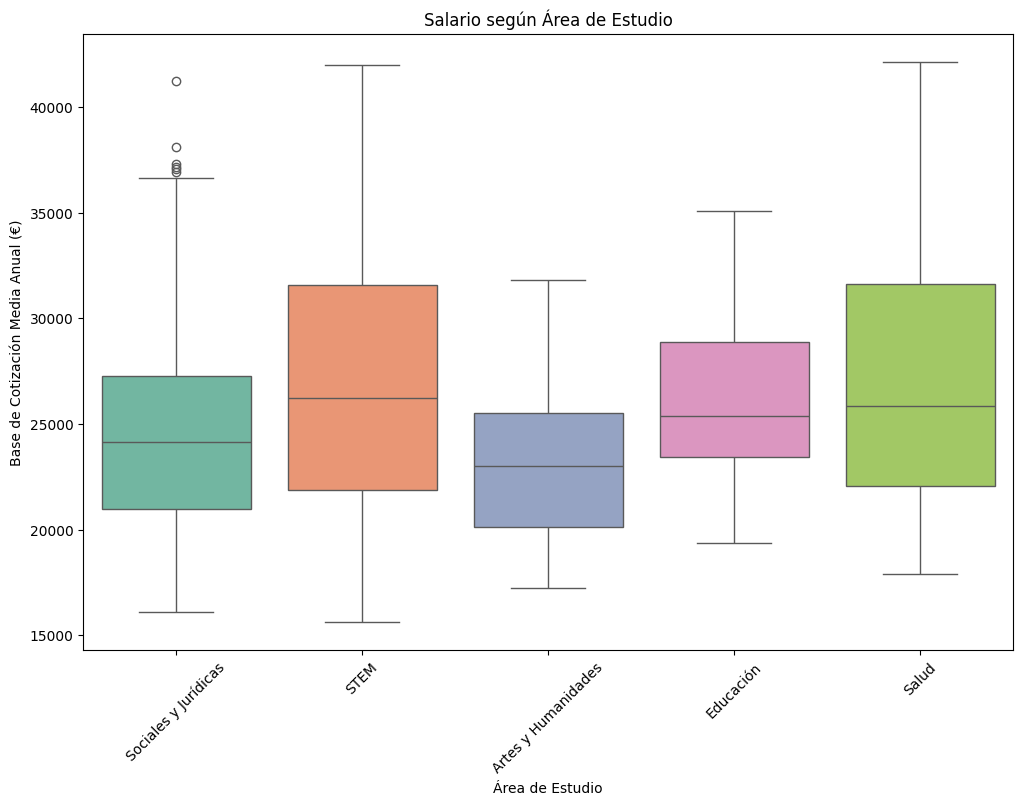

Area
STEM                    199
Sociales y Jurídicas    164
Salud                   128
Artes y Humanidades      56
Educación                56
Name: count, dtype: int64


In [ ]:
# Ahora voy a usar sns para hacer un boxplot entre las categorías:
plt.figure(figsize=(12, 8))
sns.boxplot(data=datos, x='Area', y='BCM. Anual', palette='Set2')
plt.title('Salario según Área de Estudio')
plt.xlabel('Área de Estudio')
plt.ylabel('Base de Cotización Media Anual (€)')
plt.xticks(rotation=45)
plt.show()

# Ahora quiero ver cuantas observaciones hay por cada area:
conteo_areas = datos['Area'].value_counts()
print(conteo_areas)

===== NÚMERO DE OBSERVACIONES POR ÁREA Y UNIVERSIDAD =====
Tipo_Uni              Privada  Pública
Area                                  
Artes y Humanidades        25       31
Educación                  24       32
STEM                       79      120
Salud                      60       68
Sociales y Jurídicas       79       85


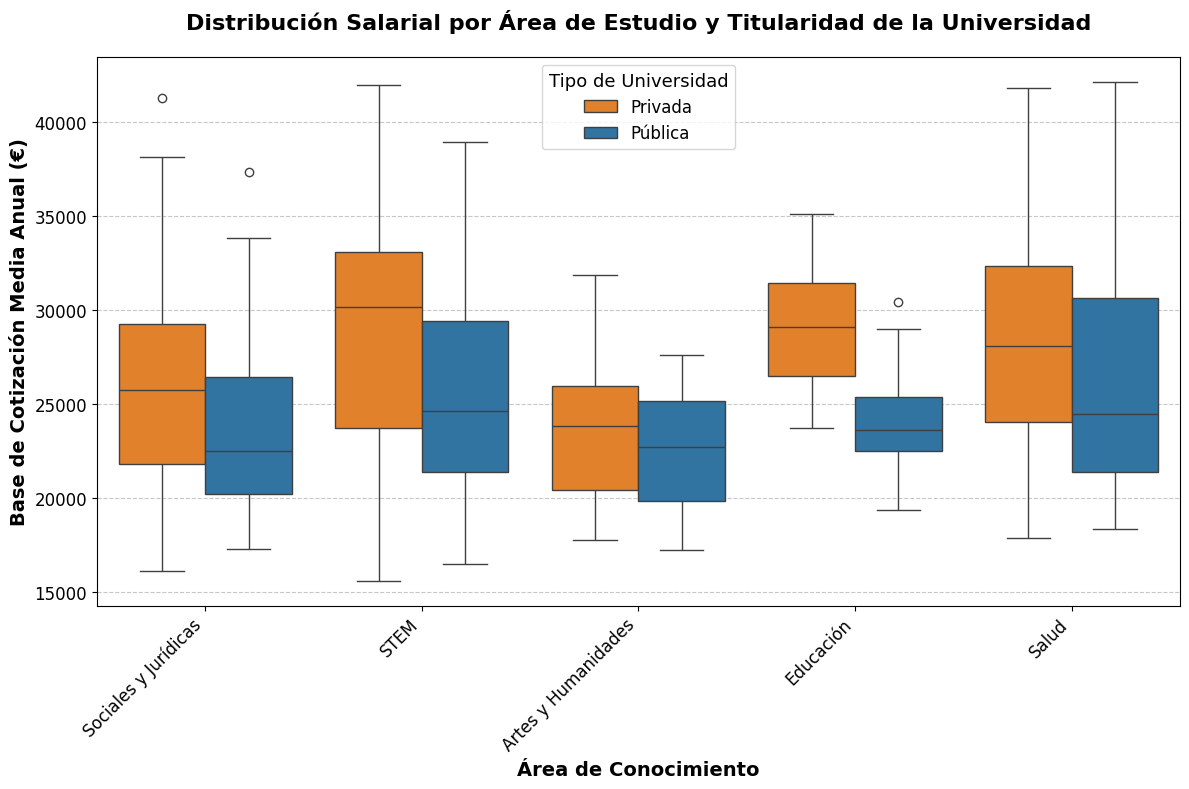

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ver cuántas observaciones hay por cada área y por tipo de universidad
conteo_areas_tipo = datos.groupby(['Area', 'Tipo_Uni']).size().unstack(fill_value=0)
print("===== NÚMERO DE OBSERVACIONES POR ÁREA Y UNIVERSIDAD =====")
print(conteo_areas_tipo)

# 2. Hacer el Boxplot separado por Pública y Privada
plt.figure(figsize=(12, 8))

# Añadimos hue='Tipo_Uni' para que haga dos cajas por cada Área
sns.boxplot(data=datos,
            x='Area',
            y='BCM. Anual',
            hue='Tipo_Uni',
            palette={'Pública': '#1f77b4', 'Privada': '#ff7f0e'})

# Ajustes de diseño para el TFG
plt.title('Distribución Salarial por Área de Estudio y Titularidad de la Universidad', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Área de Conocimiento', fontsize=14, fontweight='bold')
plt.ylabel('Base de Cotización Media Anual (€)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Tipo de Universidad', title_fontsize='13', fontsize='12')

plt.grid(axis='y', linestyle='--', alpha=0.7) # Líneas de fondo para ver mejor los valores del salario
plt.tight_layout()

# Guardar la imagen para el Word
plt.savefig("boxplot_salarios_universidad.png", dpi=300)
plt.show()

In [ ]:
from scipy import stats

# Hacemos el test de Shapiro-Wilk a la variable BCM Anual
estadistico, p_valor = stats.shapiro(datos['BCM. Anual'])

print(f"Estadístico de Shapiro-Wilk: {estadistico:.4f}")
print(f"P-valor: {p_valor:.10f}")

if p_valor < 0.05:
    print("Conclusión: Rechazamos H0. La variable NO sigue una distribución normal.")
else:
    print("Conclusión: No podemos rechazar H0. La variable sigue una distribución normal.")

Estadístico de Shapiro-Wilk: 0.9652
P-valor: 0.0000000001
Conclusión: Rechazamos H0. La variable NO sigue una distribución normal.


In [ ]:
#datos.to_clipboard()

In [ ]:
# 2. MODELO CON INTERACCIONES (Privada x Area)
# Usamos 'Salud' como área de referencia
formula_interaccion2 = "Q('BCM. Anual') ~ Dummy_Privada + C(Area, Treatment(reference='Salud'))"
# Ajustamos el modelo usando errores robustos (HC3) como tenías antes
modelo_interaccion2 = smf.ols(formula_interaccion2, data=datos).fit(cov_type='HC3')

print("================ MODELO CON INTERACCIÓN ===================")
print(modelo_interaccion2.summary())

================ MODELO CON INTERACCIÓN ===================
                            OLS Regression Results                            
Dep. Variable:        Q('BCM. Anual')   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     19.46
Date:                Sun, 24 May 2026   Prob (F-statistic):           5.65e-18
Time:                        09:55:50   Log-Likelihood:                -6014.9
No. Observations:                 603   AIC:                         1.204e+04
Df Residuals:                     597   BIC:                         1.207e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------

In [ ]:
# 2. MODELO CON INTERACCIONES (Privada x Area)
# Usamos 'Salud' como área de referencia
formula_interaccion3 = "Q('BCM. Anual') ~ Dummy_Privada*C(Area, Treatment(reference='Salud'))"

# Ajustamos el modelo usando errores robustos (HC3) como tenías antes
modelo_interaccion3 = smf.ols(formula_interaccion3, data=datos).fit(cov_type='HC3')

print("================ MODELO CON INTERACCIÓN ===================")
print(modelo_interaccion3.summary())

================ MODELO CON INTERACCIÓN ===================
                            OLS Regression Results                            
Dep. Variable:        Q('BCM. Anual')   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     13.84
Date:                Sun, 24 May 2026   Prob (F-statistic):           2.57e-20
Time:                        09:55:50   Log-Likelihood:                -6012.2
No. Observations:                 603   AIC:                         1.204e+04
Df Residuals:                     593   BIC:                         1.209e+04
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
------

In [ ]:
# Quiero quitar de mi base de datos las observaciones que tiene area = "STEM", "Sociales y Jurídicas" y "Salud"
areas_a_eliminar = ['STEM', 'Sociales y Jurídicas', 'Salud']
datos_filtrados = datos[~datos['Area'].isin(areas_a_eliminar)]

formula_interaccion4 = "Q('BCM. Anual') ~ Dummy_Privada*C(Area, Treatment(reference='Artes y Humanidades'))"

# Ajustamos el modelo usando errores robustos (HC3) como tenías antes
modelo_interaccion4 = smf.ols(formula_interaccion4, data=datos_filtrados).fit(cov_type='HC3')

print("================ MODELO CON INTERACCIÓN ===================")
print(modelo_interaccion4.summary())


================ MODELO CON INTERACCIÓN ===================
                            OLS Regression Results                            
Dep. Variable:        Q('BCM. Anual')   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     21.64
Date:                Sun, 24 May 2026   Prob (F-statistic):           4.76e-11
Time:                        09:55:50   Log-Likelihood:                -1059.8
No. Observations:                 112   AIC:                             2128.
Df Residuals:                     108   BIC:                             2139.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                                                                     coef    std err          z      P>|z|      [0.025      0.975]
---

In [ ]:
hipotesis = """Dummy_Privada:C(Area, Treatment(reference='Artes y Humanidades'))[T.Educación] = 0
"""

test = modelo_interaccion4.f_test(hipotesis)

print(test)

<F test: F=9.380184862597854, p=0.0027690426598613745, df_denom=108, df_num=1>


In [ ]:
areas_a_eliminar2 = ['Artes y Humanidades', 'Educacion']
datos_filtrados2 = datos[~datos['Area'].isin(areas_a_eliminar2)]

formula_interaccion5 = "Q('BCM. Anual') ~ Dummy_Privada*C(Area, Treatment(reference='Salud'))"
# formula_interaccion4 = "Q('BCM. Anual') ~ Dummy_Privada + C(Area, Treatment(reference='Salud'))"

# Ajustamos el modelo usando errores robustos (HC3) como tenías antes
modelo_interaccion5 = smf.ols(formula_interaccion5, data=datos_filtrados2).fit(cov_type='HC3')

print("================ MODELO CON INTERACCIÓN ===================")
print(modelo_interaccion5.summary())

================ MODELO CON INTERACCIÓN ===================
                            OLS Regression Results                            
Dep. Variable:        Q('BCM. Anual')   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     12.55
Date:                Sun, 24 May 2026   Prob (F-statistic):           6.05e-15
Time:                        09:55:50   Log-Likelihood:                -5469.2
No. Observations:                 547   AIC:                         1.095e+04
Df Residuals:                     539   BIC:                         1.099e+04
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
------

In [ ]:
# Suponiendo que el modelo ajustado se llama model
# Ejemplo: model = smf.ols(formula, data=df).fit()

hipotesis = """
Dummy_Privada:C(Area, Treatment(reference='Salud'))[T.Educación] = 0
"""

test = modelo_interaccion5.f_test(hipotesis)

print(test)

<F test: F=5.24352920840482, p=0.02241405816184439, df_denom=539, df_num=1>


In [ ]:
# 2. MODELO CON INTERACCIONES (Privada x Area)
# Usamos 'Salud' como área de referencia
formula_interaccion = "Q('BCM. Anual') ~ Anio*Dummy_Privada + C(Area, Treatment(reference='Salud')) + Dummy_Privada:C(Area, Treatment(reference='Salud'))"

# Ajustamos el modelo usando errores robustos (HC3) como tenías antes
modelo_interaccion = smf.ols(formula_interaccion, data=datos).fit(cov_type='HC3')

print("================ MODELO CON INTERACCIÓN ===================")
print(modelo_interaccion.summary())

================ MODELO CON INTERACCIÓN ===================
                            OLS Regression Results                            
Dep. Variable:        Q('BCM. Anual')   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     54.06
Date:                Sun, 24 May 2026   Prob (F-statistic):           5.35e-82
Time:                        09:55:51   Log-Likelihood:                -5857.5
No. Observations:                 603   AIC:                         1.174e+04
Df Residuals:                     591   BIC:                         1.179e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
------

In [ ]:
hipotesis = """
Dummy_Privada:C(Area, Treatment(reference='Salud'))[T.Educación] = 0,
Dummy_Privada:C(Area, Treatment(reference='Salud'))[T.Artes y Humanidades] = 0,
Dummy_Privada:C(Area, Treatment(reference='Salud'))[T.Sociales y Jurídicas] = 0,
Dummy_Privada:C(Area, Treatment(reference='Salud'))[T.STEM] = 0
"""

test = modelo_interaccion.f_test(hipotesis)

print(test)

<F test: F=5.196699220139722, p=0.00040434335470490736, df_denom=591, df_num=4>


In [ ]:
# 1. Creamos la variable Dummy para la Pública (1 = Pública, 0 = Privada)
datos['Dummy_Publica'] = (datos['Tipo_Uni'] == 'Pública').astype(int)

# 2. Escribimos la fórmula.
# Ahora la Privada es la referencia oculta (el cero) y medimos el efecto de la Pública.
formula_publica = "Q('BCM. Anual') ~ Anio + Dummy_Mujer + Dummy_Publica + C(Area, Treatment(reference='Salud')) + Dummy_Publica:C(Area, Treatment(reference='Salud'))"

# 3. Ajustamos el modelo con errores robustos (HC3)
modelo_publica = smf.ols(formula_publica, data=datos).fit(cov_type='HC3')

print("================ MODELO DESDE LA PERSPECTIVA DE LA PÚBLICA =================")
print(modelo_publica.summary())

================ MODELO DESDE LA PERSPECTIVA DE LA PÚBLICA =================
                            OLS Regression Results                            
Dep. Variable:        Q('BCM. Anual')   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     66.67
Date:                Sun, 24 May 2026   Prob (F-statistic):           5.21e-96
Time:                        09:55:51   Log-Likelihood:                -5839.6
No. Observations:                 603   AIC:                         1.170e+04
Df Residuals:                     591   BIC:                         1.176e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                                                                                  coef    std err          z      P>|z|      [0.025  

===== NÚMERO DE EGRESADOS POR ÁREA =====
Area
STEM                    199
Sociales y Jurídicas    164
Salud                   128
Artes y Humanidades      56
Educación                56
Name: count, dtype: int64

Total de datos agrupados: 603


/tmp/ipykernel_1617/236816171.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=datos, x='Area', order=conteo_areas.index, palette='viridis')


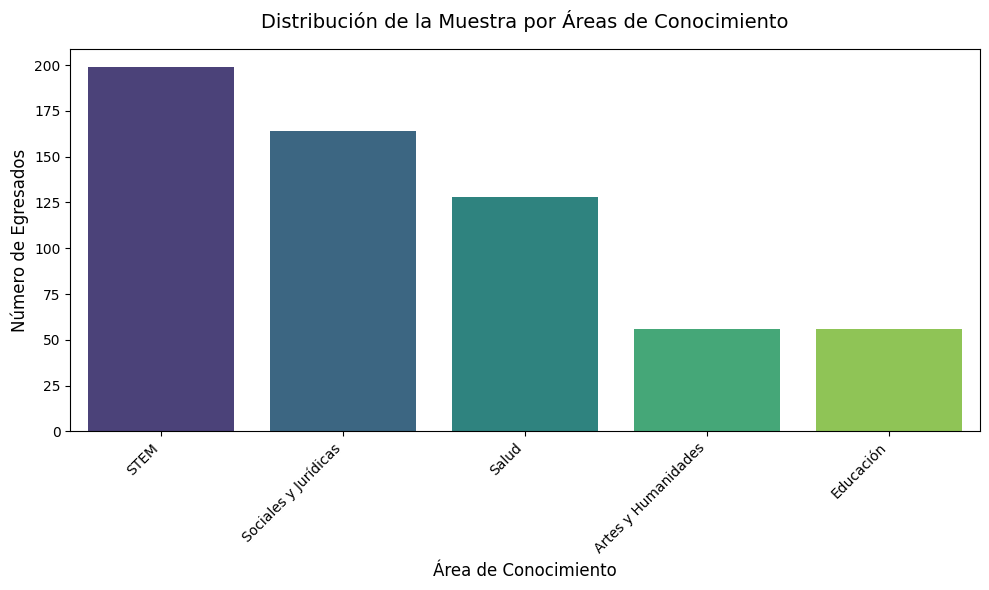

In [ ]:
# 1. Contar cuántos datos hay en cada Área
conteo_areas = datos['Area'].value_counts()

print("===== NÚMERO DE EGRESADOS POR ÁREA =====")
print(conteo_areas)
print("\nTotal de datos agrupados:", conteo_areas.sum())

# 2. Hacer un gráfico de barras para el TFG
plt.figure(figsize=(10, 6))
sns.countplot(data=datos, x='Area', order=conteo_areas.index, palette='viridis')

# Ajustes de diseño para que quede bonito
plt.title('Distribución de la Muestra por Áreas de Conocimiento', fontsize=14, pad=15)
plt.xlabel('Área de Conocimiento', fontsize=12)
plt.ylabel('Número de Egresados', fontsize=12)
plt.xticks(rotation=45, ha='right') # Gira los nombres para que se lean bien
plt.tight_layout()

# Mostrar el gráfico
plt.show()

===== NÚMERO DE EGRESADOS POR ÁREA Y UNIVERSIDAD =====
Tipo_Uni              Privada  Pública
Area                                  
Artes y Humanidades        25       31
Educación                  24       32
STEM                       79      120
Salud                      60       68
Sociales y Jurídicas       79       85

Total de datos agrupados: 603


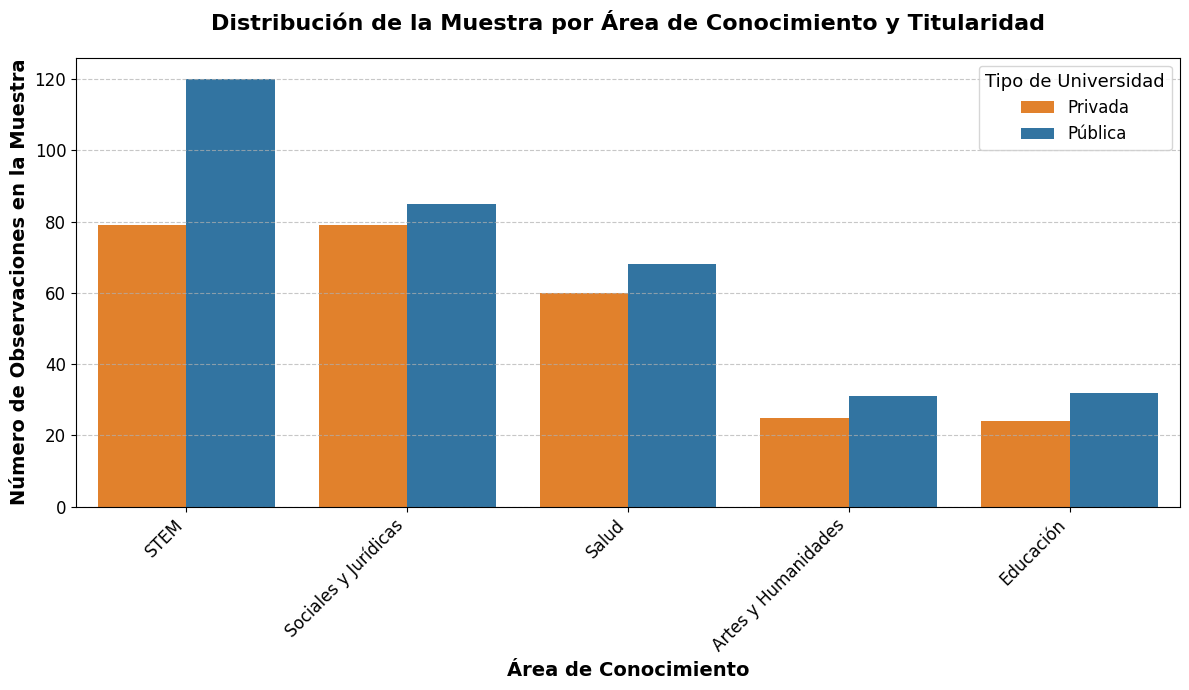

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Contar los datos por Área y por Tipo de Universidad para verlo en texto
conteo_areas_tipo = datos.groupby(['Area', 'Tipo_Uni']).size().unstack(fill_value=0)

print("===== NÚMERO DE EGRESADOS POR ÁREA Y UNIVERSIDAD =====")
print(conteo_areas_tipo)
print("\nTotal de datos agrupados:", datos.shape[0])

# 2. Hacer un gráfico de barras agrupadas para el TFG
plt.figure(figsize=(12, 7))

# La clave está aquí: añadir hue='Tipo_Uni'
sns.countplot(data=datos,
              x='Area',
              hue='Tipo_Uni',
              order=datos['Area'].value_counts().index,
              palette={'Pública': '#1f77b4', 'Privada': '#ff7f0e'}) # Azul para Pública, Naranja para Privada

# Ajustes de diseño para que quede de nivel universitario
plt.title('Distribución de la Muestra por Área de Conocimiento y Titularidad', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Área de Conocimiento', fontsize=14, fontweight='bold')
plt.ylabel('Número de Observaciones en la Muestra', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Tipo de Universidad', title_fontsize='13', fontsize='12')

plt.grid(axis='y', linestyle='--', alpha=0.7) # Añade unas líneas horizontales de fondo
plt.tight_layout()

# Mostrar y guardar el gráfico
plt.savefig("grafico_areas_universidad.png", dpi=300) # Lo guarda en alta calidad para el Word
plt.show()

In [ ]:
import statsmodels.formula.api as smf

# Definimos la fórmula con la Interacción: Privada * Área
# Usamos Anio (limpio) y Dummy_Mujer como variables de control
formula_interaccion = "Q('BCM. Anual') ~ Dummy_Privada + Dummy_Mujer + Anio + Area + Dummy_Privada:Area"

# Ajustamos el modelo con errores robustos (HC3) por la heterocedasticidad que demostramos antes
modelo_interaccion = smf.ols(formula_interaccion, data=datos).fit(cov_type='HC3')

print("=== RESULTADOS DEL MODELO DE INTERACCIONES ===")
print(modelo_interaccion.summary())

=== RESULTADOS DEL MODELO DE INTERACCIONES ===
                            OLS Regression Results                            
Dep. Variable:        Q('BCM. Anual')   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     66.67
Date:                Sun, 24 May 2026   Prob (F-statistic):           5.21e-96
Time:                        09:55:52   Log-Likelihood:                -5839.6
No. Observations:                 603   AIC:                         1.170e+04
Df Residuals:                     591   BIC:                         1.176e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

In [ ]:
# Quiero quitar de mi base de datos las observaciones que tiene area = "Artes y Humanidades, y Educación"
areas_a_eliminar = ['Artes y Humanidades','Educación']
datos_filtrados = datos[~datos['Area'].isin(areas_a_eliminar)]

formula_interaccion6 = "Q('BCM. Anual') ~ Dummy_Privada*C(Area, Treatment(reference='Salud'))"

# Ajustamos el modelo usando errores robustos (HC3) como tenías antes
modelo_interaccion6 = smf.ols(formula_interaccion6, data=datos_filtrados).fit(cov_type='HC3')

print("================ MODELO CON INTERACCIÓN ===================")
print(modelo_interaccion6.summary())


================ MODELO CON INTERACCIÓN ===================
                            OLS Regression Results                            
Dep. Variable:        Q('BCM. Anual')   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     9.748
Date:                Sun, 24 May 2026   Prob (F-statistic):           6.90e-09
Time:                        09:55:52   Log-Likelihood:                -4928.8
No. Observations:                 491   AIC:                             9870.
Df Residuals:                     485   BIC:                             9895.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
------